<a href="https://colab.research.google.com/github/ene23033/repository/blob/master/pypsaJan1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install pypsa
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [14]:
network=pypsa.Network()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [15]:
# Add the missing buses
buses = ["Solar", "Wind", "Coal", "PHES", "India"]
for bus in buses:
    if bus not in network.buses.index:
        network.add("Bus", bus)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [16]:
network.add("Generator", "Solar", bus= "India", p_nom_extendable= True,carrier= "solar", capital_cost=0.42, marginal_cost=0.003696, efficiency=0.20)
network.add("Generator", "Wind", bus= "India", p_nom_extendable= True,carrier= "wind", capital_cost=0.86, marginal_cost=0.0172, efficiency=0.40)
network.add("Generator", "Coal", bus= "India", p_nom_extendable= False,carrier= "coal", capital_cost=1.12, marginal_cost=0.028, efficiency=0.35)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



Index(['Coal'], dtype='object')

In [17]:
snapshots = pd.date_range(start="2023-01-01 00:00:00", end="2023-12-31 23:00:00", freq="h")
snapshots = snapshots.tz_localize(None)
network.set_snapshots(snapshots)
# network.set_snapshots(snapshots)
print(network.snapshots)

DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq='h')


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [18]:
snapshots = pd.date_range(
    start="2023-01-01 00:00:00", end="2023-12-31 23:00:00", freq="h", tz="Asia/Kolkata"
)
snapshots = snapshots.tz_convert("UTC").tz_localize(None)  # Convert to UTC and remove timezone info

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [19]:
demand_data = pd.read_excel("/content/Demand.xlsx")
network.add("Load","Indian_Load",bus="India", p_set=demand_data["Demand"].values)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



Index(['Indian_Load'], dtype='object')

In [20]:
network.add("StorageUnit","PHES",bus="India",p_nom_extendable= True, capital_cost=200,efficiency_dispatch=0.80)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



Index(['PHES'], dtype='object')

In [21]:
!pip install pyomo
!apt install glpk-utils
!pip install glpk

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
glpk-utils is already the newest version (5.0-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
  Using cached glpk-0.4.8.tar.gz (160 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for glpk (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for glpk
Failed to build glpk
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (glpk)


In [22]:
network.optimize()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.

Index(['Solar', 'Wind', 'Coal'], dtype='object', name='Generator')
Index(['Solar', 'Wind', 'Coal', 'PHES', 'India'], dtype='object', name='Bus')
{'Solar', 'PHES', 'Coal', 'Wind'}
Index(['Solar', 'Wind', 'Coal'], dtype='object', name='Generator')
Index(['Solar', 'Wind', 'Coal', 'PHES', 'India'], dtype='object', name='Bus')
{'Solar', 'PHES', 'Coal', 'Wind'}
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 19.95it/s]


('ok', 'optimal')

In [23]:
print(network.generators_t.p)
print(network.storage_units_t.p)

Generator                  Solar  Wind  Coal
snapshot                                    
2023-01-01 00:00:00  191901.0026  -0.0  -0.0
2023-01-01 01:00:00  186913.6215  -0.0  -0.0
2023-01-01 02:00:00  182420.6798  -0.0  -0.0
2023-01-01 03:00:00  181334.4707  -0.0  -0.0
2023-01-01 04:00:00  185064.5308  -0.0  -0.0
...                          ...   ...   ...
2023-12-31 19:00:00  242035.7727  -0.0  -0.0
2023-12-31 20:00:00  227317.8291  -0.0  -0.0
2023-12-31 21:00:00  217395.4806  -0.0  -0.0
2023-12-31 22:00:00  208717.2352  -0.0  -0.0
2023-12-31 23:00:00  202172.3370  -0.0  -0.0

[8760 rows x 3 columns]
StorageUnit          PHES
snapshot                 
2023-01-01 00:00:00   0.0
2023-01-01 01:00:00   0.0
2023-01-01 02:00:00   0.0
2023-01-01 03:00:00   0.0
2023-01-01 04:00:00   0.0
...                   ...
2023-12-31 19:00:00   0.0
2023-12-31 20:00:00   0.0
2023-12-31 21:00:00   0.0
2023-12-31 22:00:00   0.0
2023-12-31 23:00:00   0.0

[8760 rows x 1 columns]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



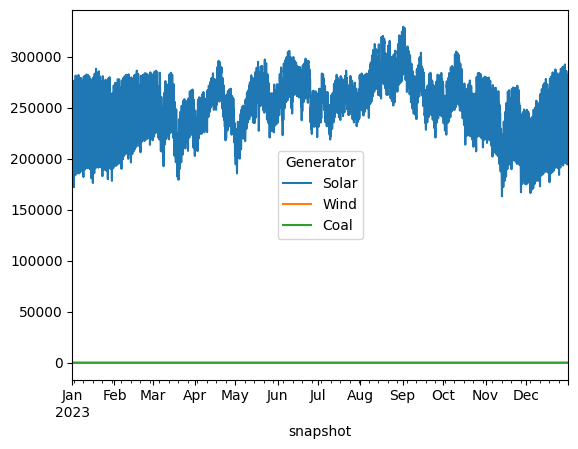

In [24]:
network.generators_t.p.plot()
plt.show()